In [96]:
# Domain Adaptation Model Testing Notebook
# Load and test trained DA models with comprehensive evaluation

import sys
sys.path.append("..")
import os
import logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s"
)

import torch
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence, pack_sequence, pack_padded_sequence, unpack_sequence
import numpy as np
import yaml
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from tqdm import tqdm

from copy import deepcopy

from src.models.base_models import create_model
from src.models.domain_discriminator import DomainDiscriminator, create_da_model
from src.data.hcut_numu_dataset import HCutNuMuDataset, create_hcut_numu_dataloader_from_ds

# 0. Experiment selection

In [97]:
# Set up paths and experiment
EXPERIMENT_DIR = Path("../experiments/numu/da_hcut5_numu_260206_smallnn_bigds_middleddnoreg_0.lambda_first_aug")
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print(f"Testing experiment: {EXPERIMENT_DIR.name}")
print(f"Device: {DEVICE}")

SAVING_SUFFIX = "_all"

report_dir = f"{EXPERIMENT_DIR}/report{SAVING_SUFFIX}"
os.makedirs(report_dir, exist_ok=True)

fig_dir = f"{report_dir}/figures/"
os.makedirs(fig_dir, exist_ok=True)

Testing experiment: da_hcut5_numu_260206_smallnn_bigds_middleddnoreg_0.lambda_first_aug
Device: cuda:0


In [98]:
# Load configuration files
config_path = EXPERIMENT_DIR / "da_config.yaml"
norm_config_path = EXPERIMENT_DIR / "normalization_config.yaml"

with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

with open(norm_config_path, 'r') as f:
    normalization_config = yaml.safe_load(f)

print("Configuration loaded:")
print(f"- Model type: {config['model']['type']}")
print(f"- Feature extractor d_model: {config['model']['feature_extractor']['d_model']}")
print(f"- Seed: {config['experiment']['seed']}")
print(f"- Max hits: {config['data']['max_hits']}")

Configuration loaded:
- Model type: numu
- Feature extractor d_model: 64
- Seed: 43
- Max hits: 500


# 1. Load trained models: basic + domain discriminator

In [99]:
# Load trained models from best checkpoint
checkpoint_path = EXPERIMENT_DIR / "best_da_model.pth"
print(f"Loading checkpoint from: {checkpoint_path}")

checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)

# Create and load base model
model = create_model(config['model'])
model.load_state_dict(checkpoint['base_model_state_dict'])
model.to(DEVICE)
model.eval()

# Create and load domain discriminator
feature_dim = config['model']['feature_extractor']['d_model']
domain_discriminator = DomainDiscriminator(
    input_dim=feature_dim,
    **config['domain_adaptation']['domain_discriminator']
)
domain_discriminator.load_state_dict(checkpoint['domain_discriminator_state_dict'])
domain_discriminator.to(DEVICE)
domain_discriminator.eval()

print("Models loaded successfully:")
print(f"- Epoch: {checkpoint.get('epoch', 'unknown')}")
print(f"- Best metric: {checkpoint.get('best_metric', 'unknown')}")
print(f"- Base model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"- Domain discriminator parameters: {sum(p.numel() for p in domain_discriminator.parameters()):,}")

2026-02-09 19:38:50,427 [INFO] Created AttentionFeatureExtractor: 5→64, 2 layers, 4 heads, pooling=cls
2026-02-09 19:38:50,429 [INFO] Created BinaryClassifier: 64→[32, 16]→1, dropout=0.0, batch_norm=False
2026-02-09 19:38:50,430 [INFO] Created StandardNeutrinoModel with 53633 parameters


Loading checkpoint from: ../experiments/numu/da_hcut5_numu_260206_smallnn_bigds_middleddnoreg_0.lambda_first_aug/best_da_model.pth


2026-02-09 19:38:50,439 [INFO] Created DomainDiscriminator: 64→[32, 16]→1, dropout=0.0, batch_norm=False, gradient_reversal=True


Models loaded successfully:
- Epoch: 27
- Best metric: 0.9678110955929451
- Base model parameters: 53,633
- Domain discriminator parameters: 2,625


# 2. Load Test Datasets

In [100]:
# Load test datasets for source (MC) and target (Exp) domains
# Automatically use event ranges after training data to ensure no overlap

source_config = config['data']['source_domain']
target_config = config['data']['target_domain']
h_min = source_config['h_min_cut']

# Get training event counts from config to set test start positions
train_events_per_particle = source_config['events_per_particle']
train_exp_events = target_config['events_per_particle'].get('exp', 0)

print(f"h_min threshold: {h_min}")
print(f"\nTraining data used (start_event for test):")
for particle, count in train_events_per_particle.items():
    print(f"  {particle}: {count}")
print(f"  exp: {train_exp_events}")

# Test set size (configurable)
TEST_EVENTS_PER_PARTICLE = 100000

# Build sampling config with start_event = training count (no overlap)
source_sampling_config = {
    particle: {'mode': 'range', 'start_event': count}
    for particle, count in train_events_per_particle.items()
}

# Load source domain (MC)
source_test_dataset = HCutNuMuDataset(
    h5_path=source_config['h5_path'],
    events_per_particle={p: TEST_EVENTS_PER_PARTICLE for p in train_events_per_particle.keys()},
    particle_types=source_config['particle_types'],
    neutrino_types=source_config['neutrino_types'],
    h_min=h_min,
    max_hits=config['data']['max_hits'],
    sampling_config=source_sampling_config,
    device='cpu',
    seed=config['experiment']['seed'],
    shuffle_events=False,  # Keep order for reproducibility
    balance_classes=False  # Don't balance for testing
)

# Load target domain (Exp)
target_test_dataset = HCutNuMuDataset(
    h5_path=target_config['h5_path'],
    events_per_particle={'exp': TEST_EVENTS_PER_PARTICLE},
    particle_types=['exp'],
    neutrino_types=[],
    h_min=h_min,
    max_hits=config['data']['max_hits'],
    sampling_config={'exp': {'mode': 'range', 'start_event': train_exp_events}},
    device='cpu',
    seed=config['experiment']['seed'],
    shuffle_events=False,
    balance_classes=False
)

print(f"\nSource (MC) test dataset: {len(source_test_dataset)} events")
print(f"  Signal: {source_test_dataset.n_signal}, Background: {source_test_dataset.n_background}")
print(f"\nTarget (Exp) test dataset: {len(target_test_dataset)} events")
print(f"  Signal: {target_test_dataset.n_signal}, Background: {target_test_dataset.n_background}")

h_min threshold: 5

Training data used (start_event for test):
  muatm_2020: 1200000
  nuatm_2020: 600000
  nue2_2020: 600000
  exp: 400000


2026-02-09 19:38:51,089 [INFO] Lazy range loading for muatm_2020: 100000 events loaded (range 1200000-1300000)
2026-02-09 19:38:55,141 [INFO] Loaded 100000 events for muatm_2020
2026-02-09 19:38:55,160 [INFO] Loaded 100000 events from muatm_2020 (neutrino_type=False)
2026-02-09 19:38:55,161 [INFO]   -> Signal (1): 0, Background (0): 100000
2026-02-09 19:38:55,464 [INFO] Lazy range loading for nue2_2020: 100000 events loaded (range 600000-700000)
2026-02-09 19:38:58,812 [INFO] Loaded 100000 events for nue2_2020
2026-02-09 19:38:58,834 [INFO] Loaded 100000 events from nue2_2020 (neutrino_type=True)
2026-02-09 19:38:58,835 [INFO]   -> Signal (1): 79212, Background (0): 20788
2026-02-09 19:38:58,841 [INFO]   -> Average signal hits per event: 11.8
2026-02-09 19:38:59,129 [INFO] Lazy range loading for nuatm_2020: 100000 events loaded (range 600000-700000)
2026-02-09 19:39:02,152 [INFO] Loaded 100000 events for nuatm_2020
2026-02-09 19:39:02,173 [INFO] Loaded 100000 events from nuatm_2020 (ne


Source (MC) test dataset: 300000 events
  Signal: 111669, Background: 188331

Target (Exp) test dataset: 100000 events
  Signal: 0, Background: 100000


In [101]:
# Create DataFrames for detailed event lookup and analysis

def create_event_dataframe(dataset, domain_name='source'):
    """Create a DataFrame with detailed event information for easy lookup."""
    records = []
    for i in range(len(dataset)):
        event_id = dataset.event_ids[i]
        particle_type = event_id.split(':')[0]
        is_signal = dataset.labels[i].item()
        signal_hits = dataset.signal_hit_counts[i]
        n_hits = dataset.hit_counts[i].item()
        magic_numbers = dataset.magic_numbers[i]
        signal_strings = len(np.unique(dataset.channel_ids[i][magic_numbers!=0]//36))
        
        # Determine event category
        if 'exp' in particle_type:
            # Experimental data - no MC truth available
            # signal_hits is meaningless for exp (all zeros from magic_numbers=0)
            category = 'exp'
        elif is_signal:
            if 'nuatm' in particle_type:
                category = 'signal_nuatm'
            elif 'nue2' in particle_type:
                category = 'signal_nue2'
            else:
                category = 'signal_other'
        else:
            # Background MC events
            if 'muatm' in particle_type or 'mu' in particle_type:
                if signal_hits >= h_min:
                    category = 'bg_muon_high'
                else:
                    category = 'bg_muon_low'
            elif 'nuatm' in particle_type:
                category = 'bg_nuatm'
            elif 'nue2' in particle_type:
                category = 'bg_nue2'
            else:
                category = 'bg_other'
        
        records.append({
            'idx': i,
            'event_id': event_id,
            'particle_type': particle_type,
            'is_signal': is_signal,
            'signal_hits': signal_hits,  # Note: meaningless for 'exp'
            'signal_strings': signal_strings,  # Note: meaningless for 'exp'
            'n_hits': n_hits,
            'category': category,
            'domain': domain_name
        })
    
    return pd.DataFrame(records)

# Create DataFrames
source_df = create_event_dataframe(source_test_dataset, 'MC')
target_df = create_event_dataframe(target_test_dataset, 'Exp')

print("Source (MC) event categories:")
print(source_df['category'].value_counts())
print(f"\nTarget (Exp) event categories:")
print(target_df['category'].value_counts())
print(f"\nNote: For Exp data, signal_hits is not meaningful (no MC truth)")

Source (MC) event categories:
category
signal_nue2     79212
bg_nuatm        67543
bg_muon_low     53878
bg_muon_high    46122
signal_nuatm    32457
bg_nue2         20788
Name: count, dtype: int64

Target (Exp) event categories:
category
exp    100000
Name: count, dtype: int64

Note: For Exp data, signal_hits is not meaningful (no MC truth)


In [102]:
source_df


,idx,event_id,particle_type,is_signal,signal_hits,signal_strings,n_hits,category,domain
0,0,nue2_2020:part_1025:16322,nue2_2020,True,6,2,74,signal_nue2,MC
1,1,muatm_2020:part_10032:23766,muatm_2020,False,3,1,67,bg_muon_low,MC
2,2,nue2_2020:part_1025:16323,nue2_2020,True,9,3,54,signal_nue2,MC
3,3,muatm_2020:part_10032:23767,muatm_2020,False,5,2,59,bg_muon_high,MC
4,4,nue2_2020:part_1025:16324,nue2_2020,True,10,1,58,signal_nue2,MC
...,...,...,...,...,...,...,...,...,...
299995,299995,nuatm_2020:part_1017:29607,nuatm_2020,False,3,1,69,bg_nuatm,MC
299996,299996,nuatm_2020:part_1017:29609,nuatm_2020,False,3,1,76,bg_nuatm,MC
299997,299997,nuatm_2020:part_1017:29611,nuatm_2020,False,0,0,42,bg_nuatm,MC
299998,299998,nuatm_2020:part_1017:29613,nuatm_2020,False,3,2,72,bg_nuatm,MC


In [103]:
# Helper function for detailed event lookup

def get_event_details(dataset, df, idx):
    """Get detailed information about a specific event."""
    event = dataset[idx]
    row = df[df['idx'] == idx].iloc[0]
    
    print(f"Event ID: {row['event_id']}")
    print(f"Category: {row['category']}")
    print(f"Is Signal: {row['is_signal']}")
    print(f"Signal Hits: {row['signal_hits']}")
    print(f"Total Hits: {row['n_hits']}")
    print(f"Features shape: {event['features'].shape}")
    
    return event, row

def lookup_events_by_category(df, category, n=5):
    """Lookup sample events by category."""
    subset = df[df['category'] == category]
    print(f"Category '{category}': {len(subset)} events")
    return subset.head(n)

# Example: lookup signal nuatm events
print("Sample signal_nuatm events:")
lookup_events_by_category(source_df, 'signal_nuatm')

Sample signal_nuatm events:
Category 'signal_nuatm': 32457 events


,idx,event_id,particle_type,is_signal,signal_hits,signal_strings,n_hits,category,domain
158424,158424,nuatm_2020:part_1015:7918,nuatm_2020,True,5,2,73,signal_nuatm,MC
158426,158426,nuatm_2020:part_1015:7921,nuatm_2020,True,6,2,69,signal_nuatm,MC
158428,158428,nuatm_2020:part_1015:7922,nuatm_2020,True,6,1,52,signal_nuatm,MC
158430,158430,nuatm_2020:part_1015:7925,nuatm_2020,True,7,2,79,signal_nuatm,MC
158432,158432,nuatm_2020:part_1015:7926,nuatm_2020,True,5,2,64,signal_nuatm,MC


# 3. Run Inference on Both Domains

In [104]:
@torch.no_grad()
def run_inference(model, domain_discriminator, dataset, normalization_config, batch_size=256):
    """
    Run inference on dataset and return predictions, features, and domain predictions.
    
    Returns:
        dict with:
            - class_probs: classification probabilities (signal probability)
            - class_logits: raw logits
            - domain_probs: domain discriminator probabilities (Exp probability)
            - features: extracted feature vectors
            - labels: ground truth labels
    """
    dataloader = create_hcut_numu_dataloader_from_ds(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        normalization_config=normalization_config,
        shuffle_batch=False,
        augmentation_config=None,  # No augmentation for inference
        use_polar_coords=False
    )
    
    all_class_probs = []
    all_class_logits = []
    all_domain_probs = []
    all_features = []
    all_labels = []
    
    model.eval()
    domain_discriminator.eval()
    
    for batch in tqdm(dataloader, desc="Inference"):
        # Move batch to device
        batch_gpu = {
            'features': batch['features'].to(DEVICE),
            'labels': batch['labels'].to(DEVICE),
            'mask': batch['mask'].to(DEVICE),
            'lengths': batch['lengths'].to(DEVICE)
        }
        
        # Get classification predictions
        class_logits = model(batch_gpu)
        class_probs = torch.sigmoid(class_logits)
        
        # Get extracted features for domain discriminator
        extracted_features = model.get_feature_representation(batch_gpu)
        
        # Get domain predictions
        domain_logits = domain_discriminator(extracted_features)
        domain_probs = torch.sigmoid(domain_logits)
        
        all_class_probs.append(class_probs.cpu())
        all_class_logits.append(class_logits.cpu())
        all_domain_probs.append(domain_probs.cpu())
        all_features.append(extracted_features.cpu())
        all_labels.append(batch['labels'].cpu())
    
    return {
        'class_probs': torch.cat(all_class_probs).numpy().flatten(),
        'class_logits': torch.cat(all_class_logits).numpy().flatten(),
        'domain_probs': torch.cat(all_domain_probs).numpy().flatten(),
        'features': torch.cat(all_features).numpy(),
        'labels': torch.cat(all_labels).numpy().astype(int)
    }

# Run inference on both domains
print("Running inference on Source (MC) domain...")
source_results = run_inference(model, domain_discriminator, source_test_dataset, normalization_config)

print("\nRunning inference on Target (Exp) domain...")
target_results = run_inference(model, domain_discriminator, target_test_dataset, normalization_config)

print(f"\nSource results: {len(source_results['class_probs'])} predictions")
print(f"Target results: {len(target_results['class_probs'])} predictions")

Running inference on Source (MC) domain...


Inference: 100%|██████████| 1172/1172 [00:20<00:00, 58.37it/s]



Running inference on Target (Exp) domain...


Inference: 100%|██████████| 391/391 [00:06<00:00, 59.04it/s]


Source results: 300000 predictions
Target results: 100000 predictions


In [105]:
# Add predictions to DataFrames for detailed analysis
source_df['class_prob'] = source_results['class_probs']
source_df['domain_prob'] = source_results['domain_probs']

target_df['class_prob'] = target_results['class_probs']
target_df['domain_prob'] = target_results['domain_probs']

print("Predictions added to DataFrames")
print("\nSource (MC) sample with predictions:")
source_df[['event_id', 'category', 'is_signal', 'signal_hits', 'class_prob', 'domain_prob']].head(10)

Predictions added to DataFrames

Source (MC) sample with predictions:


,event_id,category,is_signal,signal_hits,class_prob,domain_prob
0,nue2_2020:part_1025:16322,signal_nue2,True,6,0.902947,0.439428
1,muatm_2020:part_10032:23766,bg_muon_low,False,3,0.039705,0.994574
2,nue2_2020:part_1025:16323,signal_nue2,True,9,0.998815,0.249303
3,muatm_2020:part_10032:23767,bg_muon_high,False,5,0.000839,0.777259
4,nue2_2020:part_1025:16324,signal_nue2,True,10,0.999641,0.593193
5,muatm_2020:part_10032:23768,bg_muon_low,False,2,0.007258,0.966852
6,nue2_2020:part_1025:16325,signal_nue2,True,5,0.991223,0.019785
7,muatm_2020:part_10032:23769,bg_muon_low,False,4,0.153296,0.987927
8,nue2_2020:part_1025:16326,signal_nue2,True,8,0.995691,0.478762
9,muatm_2020:part_10032:23770,bg_muon_low,False,2,0.000254,0.982462


# 4. Classification Metrics by Category (Source Domain)

In [106]:
from sklearn.metrics import (
    precision_recall_curve, roc_curve, auc,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

def find_threshold_for_recall(probs, labels, target_recall=0.95):
    """Find threshold that achieves target recall on signal events."""
    precision, recall, thresholds = precision_recall_curve(labels, probs)
    # Find threshold where recall >= target_recall (recall is in descending order)
    valid_idx = np.where(recall >= target_recall)[0]
    if len(valid_idx) > 0:
        # Take the threshold with highest precision among those meeting recall target
        best_idx = valid_idx[np.argmax(precision[valid_idx])]
        if best_idx < len(thresholds):
            return thresholds[best_idx]
    return 0.0

def compute_metrics_by_category(df, threshold):
    """Compute metrics for each category at given threshold."""
    categories = df['category'].unique()
    results = []
    
    for cat in categories:
        subset = df[df['category'] == cat]
        preds = (subset['class_prob'] >= threshold).astype(int)
        labels = subset['is_signal'].astype(int)
        
        n_total = len(subset)
        n_predicted_signal = preds.sum()
        mean_prob = subset['class_prob'].mean()
        
        results.append({
            'category': cat,
            'n_events': n_total,
            'n_pred_signal': n_predicted_signal,
            'pred_signal_rate': n_predicted_signal / n_total if n_total > 0 else 0,
            'mean_prob': mean_prob,
            'std_prob': subset['class_prob'].std()
        })
    
    return pd.DataFrame(results).sort_values('category')

# Find optimal threshold for 95% signal recall
TARGET_RECALL = 0.95
optimal_threshold = find_threshold_for_recall(
    source_df['class_prob'].values,
    source_df['is_signal'].values,
    target_recall=TARGET_RECALL
)
print(f"Optimal threshold for {TARGET_RECALL*100:.0f}% signal recall: {optimal_threshold:.4f}")

# Compute AUC
auc_score = roc_auc_score(source_df['is_signal'].values, source_df['class_prob'].values)
print(f"ROC AUC: {auc_score:.4f}")

Optimal threshold for 95% signal recall: 0.2055
ROC AUC: 0.9668


In [107]:
# Detailed metrics by category at optimal threshold
print(f"\nMetrics by category at threshold {optimal_threshold:.4f}:")
print("="*80)

category_metrics = compute_metrics_by_category(source_df, optimal_threshold)
display(category_metrics)

# Classification report at optimal threshold
preds = (source_df['class_prob'] >= optimal_threshold).astype(int)
labels = source_df['is_signal'].astype(int)

print("\nClassification Report (Overall):")
print(classification_report(labels, preds, target_names=['Background', 'Signal']))


Metrics by category at threshold 0.2055:


,category,n_events,n_pred_signal,pred_signal_rate,mean_prob,std_prob
2,bg_muon_high,46122,4710,0.102120,0.062081,0.143411
1,bg_muon_low,53878,5497,0.102027,0.066172,0.122721
5,bg_nuatm,67543,19376,0.286869,0.165588,0.222070
4,bg_nue2,20788,7331,0.352655,0.206202,0.244430
3,signal_nuatm,32457,30048,0.925779,0.736362,0.282983
0,signal_nue2,79212,76038,0.959930,0.858469,0.240938



Classification Report (Overall):
              precision    recall  f1-score   support

  Background       0.96      0.80      0.88    188331
      Signal       0.74      0.95      0.83    111669

    accuracy                           0.86    300000
   macro avg       0.85      0.88      0.86    300000
weighted avg       0.88      0.86      0.86    300000



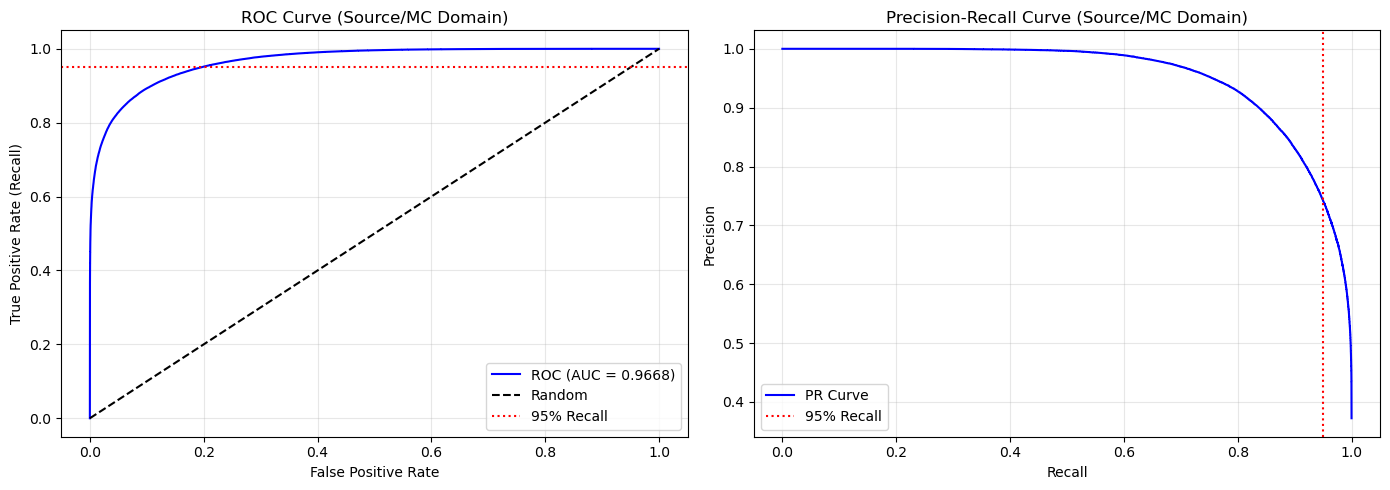

In [108]:
# Visualizations: ROC curve and Precision-Recall curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(source_df['is_signal'].values, source_df['class_prob'].values)
axes[0].plot(fpr, tpr, 'b-', label=f'ROC (AUC = {auc_score:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].axhline(y=TARGET_RECALL, color='r', linestyle=':', label=f'{TARGET_RECALL*100:.0f}% Recall')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('ROC Curve (Source/MC Domain)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(source_df['is_signal'].values, source_df['class_prob'].values)
#pr_auc = auc(recall, precision)
axes[1].plot(recall, precision, 'b-', label=f'PR Curve')
axes[1].axvline(x=TARGET_RECALL, color='r', linestyle=':', label=f'{TARGET_RECALL*100:.0f}% Recall')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve (Source/MC Domain)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{fig_dir}/roc_pr_curves.png", dpi=150, bbox_inches='tight')
plt.show()

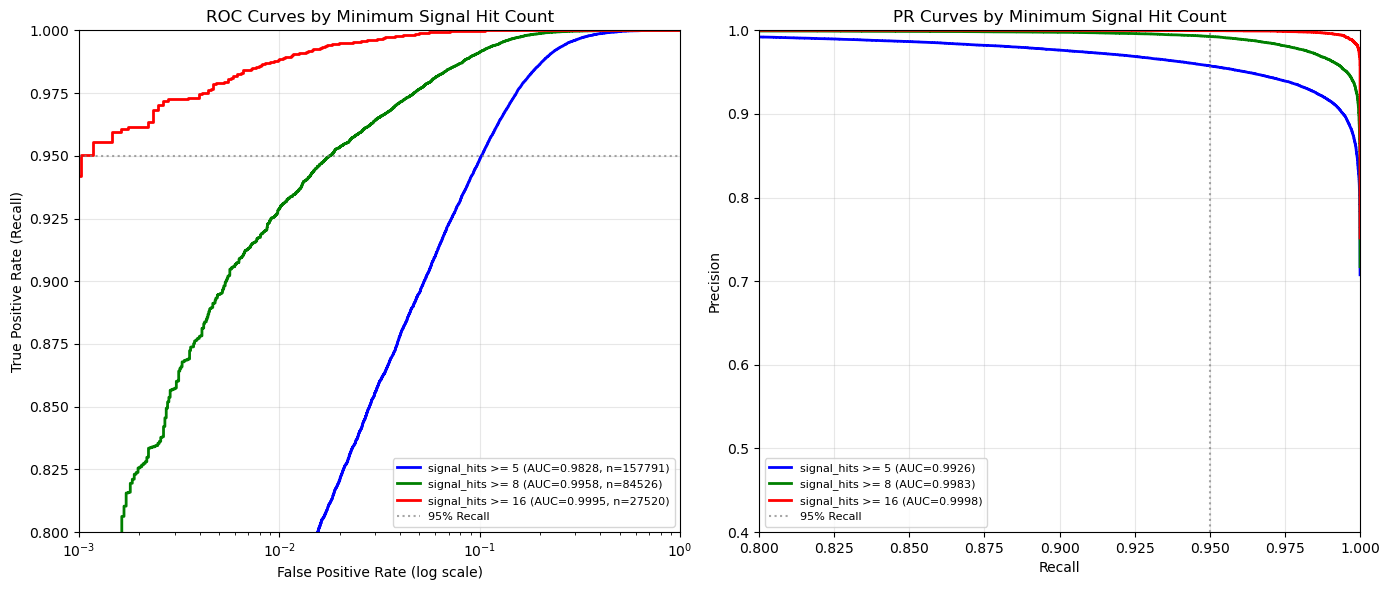


Event statistics by signal hit threshold:
  signal_hits >= 5: 157791 events (111669 signal, 46122 background)
  signal_hits >= 8: 84526 events (60639 signal, 23887 background)
  signal_hits >= 16: 27520 events (20689 signal, 6831 background)


In [109]:
# ROC and PR curves for events with minimum signal hit count cuts
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

signal_hit_thresholds = [5, 8, 16]
colors = ['blue', 'green', 'red']

for threshold, color in zip(signal_hit_thresholds, colors):
    # Filter events by minimum signal hit count
    filtered_df = source_df[source_df['signal_hits'] >= threshold]
    n_events = len(filtered_df)
    n_signal = filtered_df['is_signal'].sum()
    n_background = n_events - n_signal
    
    if n_signal > 0 and n_background > 0:
        # ROC curve
        fpr_t, tpr_t, _ = roc_curve(filtered_df['is_signal'].values, filtered_df['class_prob'].values)
        auc_t = roc_auc_score(filtered_df['is_signal'].values, filtered_df['class_prob'].values)
        axes[0].plot(fpr_t, tpr_t, color=color, linewidth=2, 
                label=f'signal_hits >= {threshold} (AUC={auc_t:.4f}, n={n_events})')
        
        # PR curve
        prec_t, rec_t, _ = precision_recall_curve(filtered_df['is_signal'].values, filtered_df['class_prob'].values)
        pr_auc_t = auc(rec_t, prec_t)
        axes[1].plot(rec_t, prec_t, color=color, linewidth=2,
                label=f'signal_hits >= {threshold} (AUC={pr_auc_t:.4f})')
    else:
        print(f"Skipping threshold {threshold}: insufficient signal ({n_signal}) or background ({n_background})")

# ROC plot styling - log scale on x-axis to spread out low FPR region
axes[0].set_xscale('log')
axes[0].axhline(y=TARGET_RECALL, color='gray', linestyle=':', alpha=0.7, label=f'{TARGET_RECALL*100:.0f}% Recall')
axes[0].set_xlabel('False Positive Rate (log scale)')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('ROC Curves by Minimum Signal Hit Count')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([1e-3, 1])
axes[0].set_ylim([0.8, 1.0])

# PR plot styling - zoom in on high-recall region
axes[1].axvline(x=TARGET_RECALL, color='gray', linestyle=':', alpha=0.7, label=f'{TARGET_RECALL*100:.0f}% Recall')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('PR Curves by Minimum Signal Hit Count')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0.8, 1.0])
axes[1].set_ylim([0.4, 1.0])

plt.tight_layout()
plt.savefig(f"{fig_dir}/roc_pr_by_min_signal_hits.png", dpi=150, bbox_inches='tight')
plt.show()

# Print statistics
print("\nEvent statistics by signal hit threshold:")
for threshold in signal_hit_thresholds:
    filtered_df = source_df[source_df['signal_hits'] >= threshold]
    n_events = len(filtered_df)
    n_signal = filtered_df['is_signal'].sum()
    n_background = n_events - n_signal
    print(f"  signal_hits >= {threshold}: {n_events} events ({n_signal} signal, {n_background} background)")

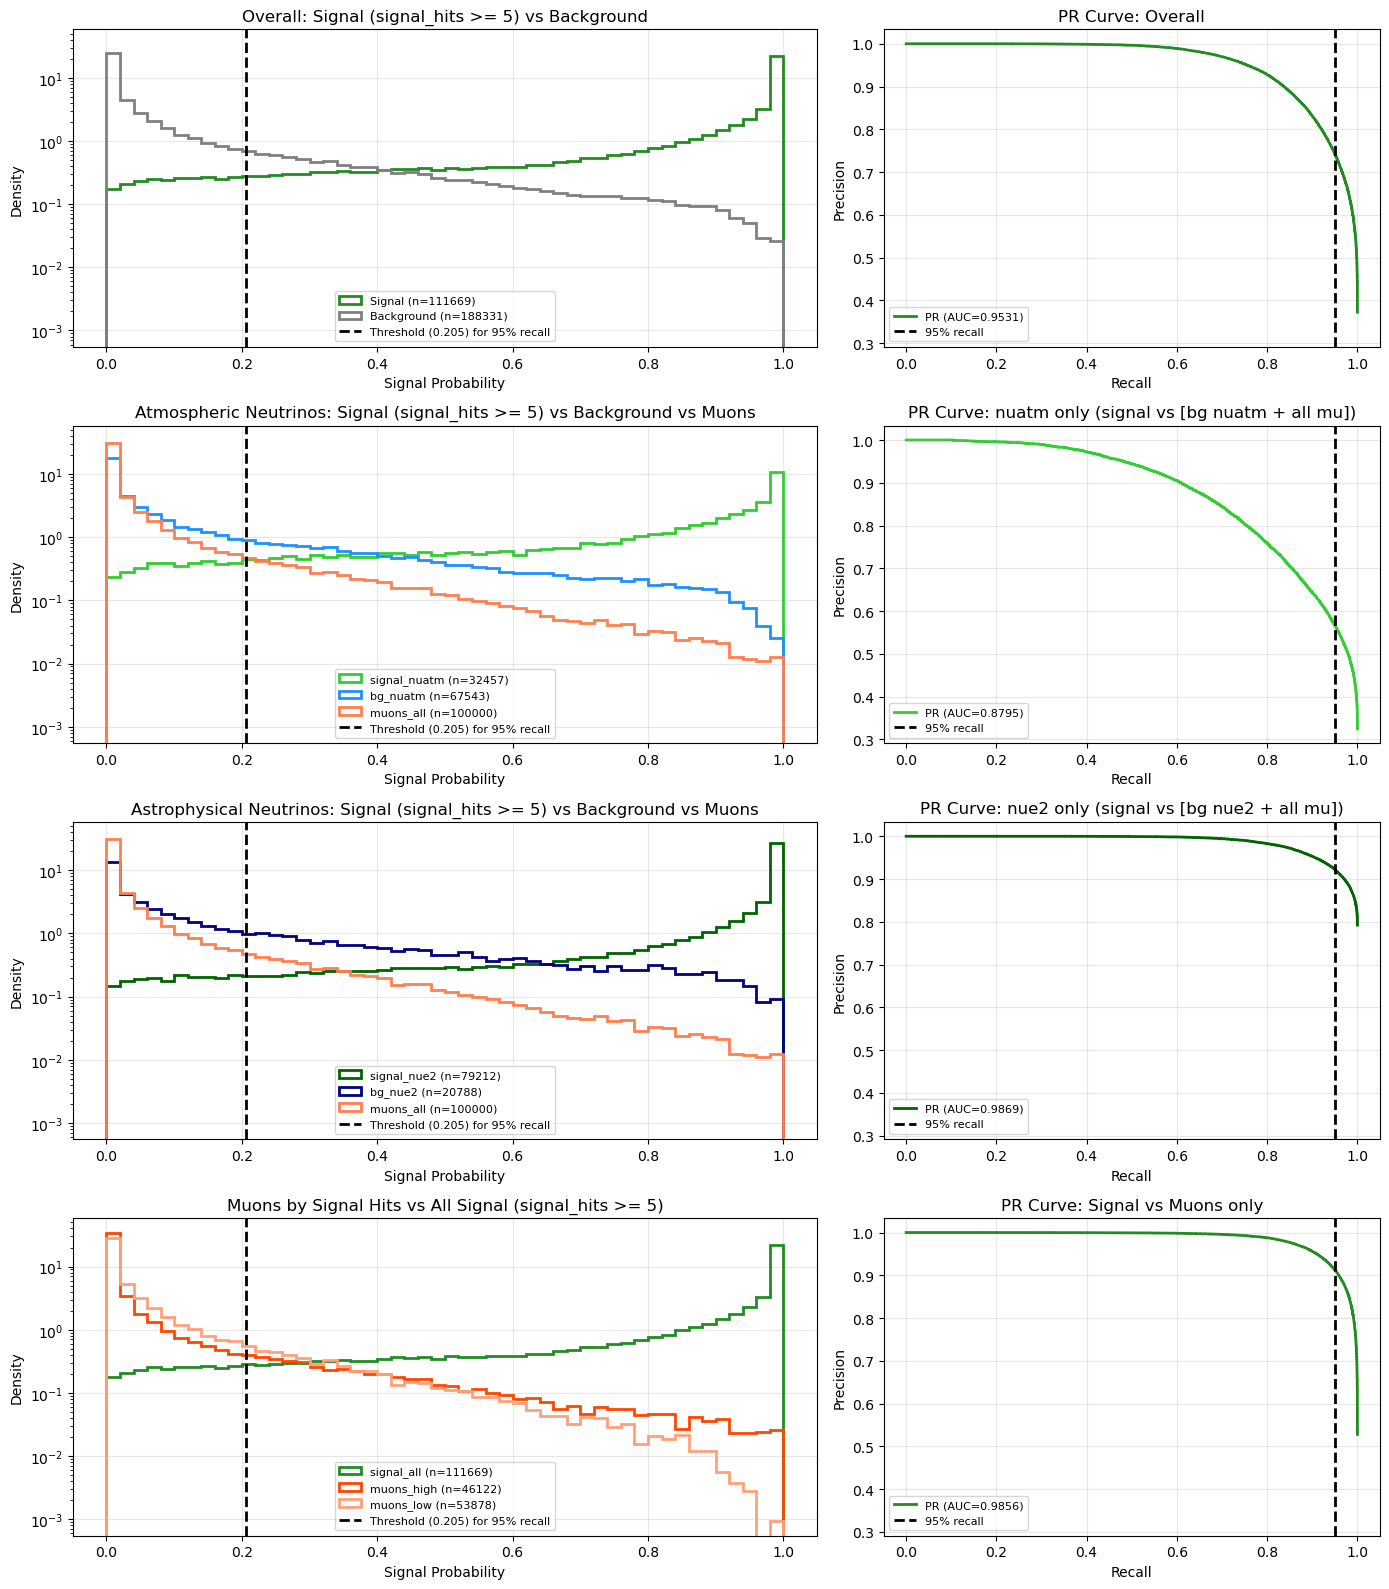

In [110]:
# Probability distributions by category (Source/MC domain) - Step histograms with PR curves
# Note: 'signal' neutrinos have signal_hits >= h_min, threshold set for 95% recall
fig, axes = plt.subplots(4, 2, figsize=(14, 16), sharey='col', width_ratios=[3,2])

bins = np.linspace(0, 1, 51)

# Get data for each category
signal_all = source_df[source_df['is_signal'] == True]['class_prob'].values
bg_all = source_df[source_df['is_signal'] == False]['class_prob'].values
signal_nuatm = source_df[source_df['category'] == 'signal_nuatm']['class_prob'].values
signal_nue2 = source_df[source_df['category'] == 'signal_nue2']['class_prob'].values
bg_nuatm = source_df[source_df['category'] == 'bg_nuatm']['class_prob'].values
bg_nue2 = source_df[source_df['category'] == 'bg_nue2']['class_prob'].values
muons_low = source_df[source_df['category'] == 'bg_muon_low']['class_prob'].values
muons_high = source_df[source_df['category'] == 'bg_muon_high']['class_prob'].values
muons_all = source_df[source_df['category'].isin(['bg_muon_low', 'bg_muon_high'])]['class_prob'].values

# Colors: signal=green, muons=coral/orange, bg neutrinos=blue
c_signal = 'forestgreen'
c_signal_nuatm = 'limegreen'
c_signal_nue2 = 'darkgreen'
c_muon = 'coral'
c_muon_high = 'orangered'
c_muon_low = 'lightsalmon'
c_bg_nuatm = 'dodgerblue'
c_bg_nue2 = 'navy'

threshold_label = f'Threshold ({optimal_threshold:.3f}) for 95% recall'

# Row 1: Overall Signal vs Background
ax = axes[0, 0]
ax.hist(signal_all, bins=bins, histtype='step', linewidth=2, 
        label=f'Signal (n={len(signal_all)})', color=c_signal, density=True)
ax.hist(bg_all, bins=bins, histtype='step', linewidth=2, 
        label=f'Background (n={len(bg_all)})', color='gray', density=True)
ax.axvline(x=optimal_threshold, color='black', linestyle='--', linewidth=2, 
           label=threshold_label)
ax.set_xlabel('Signal Probability')
ax.set_ylabel('Density')
ax.set_title(f'Overall: Signal (signal_hits >= {h_min}) vs Background')
ax.set_yscale('log')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# PR curve for overall
ax = axes[0, 1]
precision_all, recall_all, _ = precision_recall_curve(source_df['is_signal'].values, source_df['class_prob'].values)
pr_auc_all = auc(recall_all, precision_all)
ax.plot(recall_all, precision_all, color=c_signal, linewidth=2, label=f'PR (AUC={pr_auc_all:.4f})')
ax.axvline(x=0.95, color='black', linestyle='--', linewidth=2, label='95% recall')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('PR Curve: Overall')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Row 2: nuatm comparison
ax = axes[1, 0]
ax.hist(signal_nuatm, bins=bins, histtype='step', linewidth=2, 
        label=f'signal_nuatm (n={len(signal_nuatm)})', color=c_signal_nuatm, density=True)
ax.hist(bg_nuatm, bins=bins, histtype='step', linewidth=2, 
        label=f'bg_nuatm (n={len(bg_nuatm)})', color=c_bg_nuatm, density=True)
ax.hist(muons_all, bins=bins, histtype='step', linewidth=2, 
        label=f'muons_all (n={len(muons_all)})', color=c_muon, density=True)
ax.axvline(x=optimal_threshold, color='black', linestyle='--', linewidth=2, 
           label=threshold_label)
ax.set_xlabel('Signal Probability')
ax.set_ylabel('Density')
ax.set_title(f'Atmospheric Neutrinos: Signal (signal_hits >= {h_min}) vs Background vs Muons')
ax.set_yscale('log')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# PR curve for nuatm only (signal_nuatm vs bg_nuatm)
ax = axes[1, 1]
nuatm_df = source_df[source_df['category'].isin(['signal_nuatm', 'bg_nuatm'])]
precision_nuatm, recall_nuatm, _ = precision_recall_curve(nuatm_df['is_signal'].values, nuatm_df['class_prob'].values)
pr_auc_nuatm = auc(recall_nuatm, precision_nuatm)
ax.plot(recall_nuatm, precision_nuatm, color=c_signal_nuatm, linewidth=2, label=f'PR (AUC={pr_auc_nuatm:.4f})')
ax.axvline(x=0.95, color='black', linestyle='--', linewidth=2, label='95% recall')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('PR Curve: nuatm only (signal vs [bg nuatm + all mu])')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Row 3: nue2 comparison
ax = axes[2, 0]
ax.hist(signal_nue2, bins=bins, histtype='step', linewidth=2, 
        label=f'signal_nue2 (n={len(signal_nue2)})', color=c_signal_nue2, density=True)
ax.hist(bg_nue2, bins=bins, histtype='step', linewidth=2, 
        label=f'bg_nue2 (n={len(bg_nue2)})', color=c_bg_nue2, density=True)
ax.hist(muons_all, bins=bins, histtype='step', linewidth=2, 
        label=f'muons_all (n={len(muons_all)})', color=c_muon, density=True)
ax.axvline(x=optimal_threshold, color='black', linestyle='--', linewidth=2, 
           label=threshold_label)
ax.set_xlabel('Signal Probability')
ax.set_ylabel('Density')
ax.set_title(f'Astrophysical Neutrinos: Signal (signal_hits >= {h_min}) vs Background vs Muons')
ax.set_yscale('log')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# PR curve for nue2 only (signal_nue2 vs bg_nue2)
ax = axes[2, 1]
nue2_df = source_df[source_df['category'].isin(['signal_nue2', 'bg_nue2'])]
precision_nue2, recall_nue2, _ = precision_recall_curve(nue2_df['is_signal'].values, nue2_df['class_prob'].values)
pr_auc_nue2 = auc(recall_nue2, precision_nue2)
ax.plot(recall_nue2, precision_nue2, color=c_signal_nue2, linewidth=2, label=f'PR (AUC={pr_auc_nue2:.4f})')
ax.axvline(x=0.95, color='black', linestyle='--', linewidth=2, label='95% recall')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('PR Curve: nue2 only (signal vs [bg nue2 + all mu])')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Row 4: Muons vs All Signal
ax = axes[3, 0]
ax.hist(signal_all, bins=bins, histtype='step', linewidth=2, 
        label=f'signal_all (n={len(signal_all)})', color=c_signal, density=True)
ax.hist(muons_high, bins=bins, histtype='step', linewidth=2, 
        label=f'muons_high (n={len(muons_high)})', color=c_muon_high, density=True)
ax.hist(muons_low, bins=bins, histtype='step', linewidth=2, 
        label=f'muons_low (n={len(muons_low)})', color=c_muon_low, density=True)
ax.axvline(x=optimal_threshold, color='black', linestyle='--', linewidth=2, 
           label=threshold_label)
ax.set_xlabel('Signal Probability')
ax.set_ylabel('Density')
ax.set_title(f'Muons by Signal Hits vs All Signal (signal_hits >= {h_min})')
ax.set_yscale('log')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# PR curve for signal vs muons only
ax = axes[3, 1]
muon_signal_df = source_df[source_df['category'].isin(['signal_nuatm', 'signal_nue2', 'bg_muon_low', 'bg_muon_high'])]
precision_muon, recall_muon, _ = precision_recall_curve(muon_signal_df['is_signal'].values, muon_signal_df['class_prob'].values)
pr_auc_muon = auc(recall_muon, precision_muon)
ax.plot(recall_muon, precision_muon, color=c_signal, linewidth=2, label=f'PR (AUC={pr_auc_muon:.4f})')
ax.axvline(x=0.95, color='black', linestyle='--', linewidth=2, label='95% recall')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('PR Curve: Signal vs Muons only')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{fig_dir}/prob_distribution_by_category.png", dpi=150, bbox_inches='tight')
plt.show()

# 5. Source vs Target Domain Comparison (Background Events)

In [111]:
# Compare prediction distributions: MC muons vs Experimental data
# Target domain is expected to be dominated by muons -> model should predict background confidently
# If Exp events have high signal probabilities, we have domain shift issues

# Source muons (MC) - split by signal hits
source_muons_high = source_df[source_df['category'] == 'bg_muon_high']
source_muons_low = source_df[source_df['category'] == 'bg_muon_low']
source_muons_all = source_df[source_df['category'].isin(['bg_muon_high', 'bg_muon_low'])]

# Target (Exp) - all events (no MC truth to split by signal hits)
target_all = target_df[target_df['category'] == 'exp']

print("Event counts:")
print(f"  Source MC muons (high hits >= {h_min}): {len(source_muons_high)}")
print(f"  Source MC muons (low hits < {h_min}):  {len(source_muons_low)}")
print(f"  Source MC muons (all):                 {len(source_muons_all)}")
print(f"  Target Exp (all):                      {len(target_all)}")

print(f"\nPredicted as signal (threshold={optimal_threshold:.4f}):")
print(f"  MC muons (high): {(source_muons_high['class_prob'] >= optimal_threshold).mean()*100:.2f}%")
print(f"  MC muons (low):  {(source_muons_low['class_prob'] >= optimal_threshold).mean()*100:.2f}%")
print(f"  MC muons (all):  {(source_muons_all['class_prob'] >= optimal_threshold).mean()*100:.2f}%")
print(f"  Exp (all):       {(target_all['class_prob'] >= optimal_threshold).mean()*100:.2f}%")

print(f"\nMean signal probability:")
print(f"  MC muons (high): {source_muons_high['class_prob'].mean():.4f} ± {source_muons_high['class_prob'].std():.4f}")
print(f"  MC muons (low):  {source_muons_low['class_prob'].mean():.4f} ± {source_muons_low['class_prob'].std():.4f}")
print(f"  MC muons (all):  {source_muons_all['class_prob'].mean():.4f} ± {source_muons_all['class_prob'].std():.4f}")
print(f"  Exp (all):       {target_all['class_prob'].mean():.4f} ± {target_all['class_prob'].std():.4f}")

Event counts:
  Source MC muons (high hits >= 5): 46122
  Source MC muons (low hits < 5):  53878
  Source MC muons (all):                 100000
  Target Exp (all):                      100000

Predicted as signal (threshold=0.2055):
  MC muons (high): 10.21%
  MC muons (low):  10.20%
  MC muons (all):  10.21%
  Exp (all):       13.80%

Mean signal probability:
  MC muons (high): 0.0621 ± 0.1434
  MC muons (low):  0.0662 ± 0.1227
  MC muons (all):  0.0643 ± 0.1327
  Exp (all):       0.0829 ± 0.1544


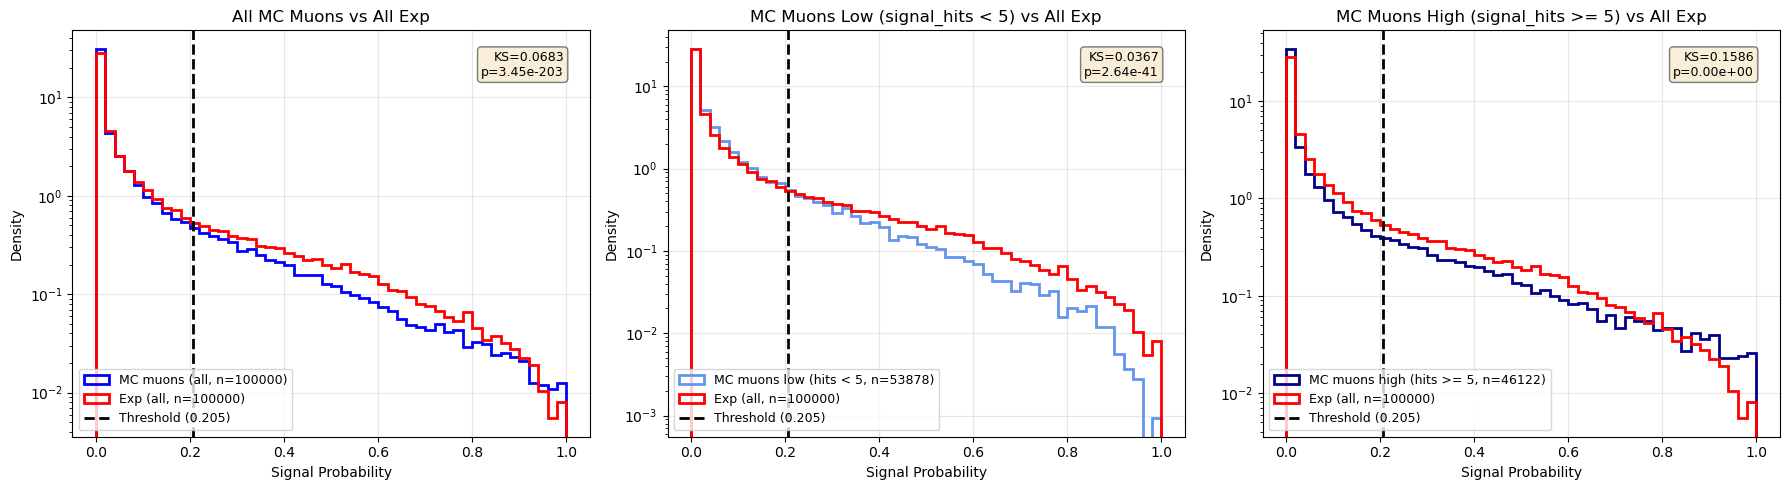


DOMAIN SHIFT ANALYSIS (KS Test Summary):
All MC muons vs Exp:     KS=0.0683, p=3.45e-203
MC muons low vs Exp:     KS=0.0367, p=2.64e-41
MC muons high vs Exp:    KS=0.1586, p=0.00e+00

Interpretation: Small KS + high p-value = similar distributions (good DA)


In [112]:
# Visualization: MC muons vs Experimental data prediction distributions (Step histograms)
from scipy.stats import ks_2samp

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
bins = np.linspace(0, 1, 51)

# Colors
c_mc_muon = 'blue'
c_mc_muon_high = 'darkblue'
c_mc_muon_low = 'cornflowerblue'
c_exp = 'red'

threshold_label = f'Threshold ({optimal_threshold:.3f})'

# Plot 1: All MC muons VS all Exp events
ax = axes[0]
ax.hist(source_muons_all['class_prob'], bins=bins, histtype='step', linewidth=2, 
        label=f'MC muons (all, n={len(source_muons_all)})', color=c_mc_muon, density=True)
ax.hist(target_all['class_prob'], bins=bins, histtype='step', linewidth=2, 
        label=f'Exp (all, n={len(target_all)})', color=c_exp, density=True)
ax.axvline(x=optimal_threshold, color='black', linestyle='--', linewidth=2, label=threshold_label)
ax.set_xlabel('Signal Probability')
ax.set_ylabel('Density')
ax.set_title('All MC Muons vs All Exp')
ax.set_yscale('log')
ax.legend(fontsize=9, loc=3)
ax.grid(True, alpha=0.3)

# KS test for plot 1
ks_stat_all, ks_pval_all = ks_2samp(source_muons_all['class_prob'], target_all['class_prob'])
ax.text(0.95, 0.95, f'KS={ks_stat_all:.4f}\np={ks_pval_all:.2e}', 
        transform=ax.transAxes, fontsize=9, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 2: Low muons (signal_hits < h_min) VS all Exp events
ax = axes[1]
ax.hist(source_muons_low['class_prob'], bins=bins, histtype='step', linewidth=2, 
        label=f'MC muons low (hits < {h_min}, n={len(source_muons_low)})', color=c_mc_muon_low, density=True)
ax.hist(target_all['class_prob'], bins=bins, histtype='step', linewidth=2, 
        label=f'Exp (all, n={len(target_all)})', color=c_exp, density=True)
ax.axvline(x=optimal_threshold, color='black', linestyle='--', linewidth=2, label=threshold_label)
ax.set_xlabel('Signal Probability')
ax.set_ylabel('Density')
ax.set_title(f'MC Muons Low (signal_hits < {h_min}) vs All Exp')
ax.set_yscale('log')
ax.legend(fontsize=9, loc=3)
ax.grid(True, alpha=0.3)

# KS test for plot 2
ks_stat_low, ks_pval_low = ks_2samp(source_muons_low['class_prob'], target_all['class_prob'])
ax.text(0.95, 0.95, f'KS={ks_stat_low:.4f}\np={ks_pval_low:.2e}', 
        transform=ax.transAxes, fontsize=9, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 3: High muons (signal_hits >= h_min) VS all Exp events
ax = axes[2]
ax.hist(source_muons_high['class_prob'], bins=bins, histtype='step', linewidth=2, 
        label=f'MC muons high (hits >= {h_min}, n={len(source_muons_high)})', color=c_mc_muon_high, density=True)
ax.hist(target_all['class_prob'], bins=bins, histtype='step', linewidth=2, 
        label=f'Exp (all, n={len(target_all)})', color=c_exp, density=True)
ax.axvline(x=optimal_threshold, color='black', linestyle='--', linewidth=2, label=threshold_label)
ax.set_xlabel('Signal Probability')
ax.set_ylabel('Density')
ax.set_title(f'MC Muons High (signal_hits >= {h_min}) vs All Exp')
ax.set_yscale('log')
ax.legend(fontsize=9, loc=3)
ax.grid(True, alpha=0.3)

# KS test for plot 3
ks_stat_high, ks_pval_high = ks_2samp(source_muons_high['class_prob'], target_all['class_prob'])
ax.text(0.95, 0.95, f'KS={ks_stat_high:.4f}\np={ks_pval_high:.2e}', 
        transform=ax.transAxes, fontsize=9, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(f"{fig_dir}/mc_muons_vs_exp_distributions.png", dpi=150, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\n" + "="*80)
print("DOMAIN SHIFT ANALYSIS (KS Test Summary):")
print("="*80)
print(f"All MC muons vs Exp:     KS={ks_stat_all:.4f}, p={ks_pval_all:.2e}")
print(f"MC muons low vs Exp:     KS={ks_stat_low:.4f}, p={ks_pval_low:.2e}")
print(f"MC muons high vs Exp:    KS={ks_stat_high:.4f}, p={ks_pval_high:.2e}")
print("\nInterpretation: Small KS + high p-value = similar distributions (good DA)")

# 6. Compare to RecoExp samples

## 6.1 Work with Reco dataset

In [113]:
import h5py
import uproot as ur
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('../../Baikal-ML')

from data.root_extractor.internal_root_paths import ExpRecoRootPaths
from data.root_extractor.main import RootFileReader

# data
names = [
        '2020/2020_cl3_run124_scl_DATA2020',
        '2020/2020_cl3_run123_scl_DATA2020',
        '2020/2020_cl3_run126_scl_DATA2020',
        '2020/2020_cl3_run128_scl_DATA2020',
        '2020/2020_cl3_run127_scl_DATA2020',
        '2020/2020_cl3_run120_scl_DATA2020',
        '2020/2020_cl3_run121_scl_nu_DATA2020',
        '2020/2020_cl3_run129_scl_DATA2020',
        '2020/2020_cl3_run125_scl_DATA2020',
        '2020/2020_cl3_run122_scl_DATA2020',
        '2020/2020_cl3_run121_scl_DATA2020'
        ]
reco_paths = [f"/net/62/home3/ivkhar/Baikal/data/initial_data/exp_data/{name}.root" for name in names]

norm_params = {
    'means': [2., 0., 0., 0., 0.],
    'stds': [60., 1370., 40., 40., 150.],
    'feature_names': ['amplitude', 'time', 'x', 'y', 'z']
}

cl3_centers = [-278.94, -97.17, 362.4]    

pulses_df = []
om_coords = []
#events_df = []
for i, path in enumerate(reco_paths):
    with RootFileReader(path, ExpRecoRootPaths(), prefix=f"{i}_") as rr:
        # events_df.append(rr.read_events_as_df())
        pulses_df.append(rr.read_pulses_as_df().to_pandas())
        #muons = rr.read_muons_as_df()
        om_coords.append(rr.read_OM_coords().to_pandas())
print(pulses_df)
pulses_df_pd = pd.concat(pulses_df, axis=0)
om_coords_pd = pd.concat(om_coords, axis=0)

exp_reco_df0 = pulses_df_pd.merge(om_coords_pd[['X','Y','Z','PulsesChID','ev_id']], how='left', on=['ev_id', 'PulsesChID']).dropna()
# Centering cluster
exp_reco_df0['X'] = exp_reco_df0['X'] - cl3_centers[0]
exp_reco_df0['Y'] = exp_reco_df0['Y'] - cl3_centers[1]
exp_reco_df0['Z'] = exp_reco_df0['Z'] - cl3_centers[2]
# Center times
times_centers = exp_reco_df0[['ev_id', 'PulsesTime']].groupby('ev_id').agg('mean').rename(columns={'PulsesTime': 't_center'})
exp_reco_df0 = exp_reco_df0.merge(times_centers, how='left', on='ev_id')
# Norm data
exp_reco_df0['PulsesTime'] = exp_reco_df0['PulsesTime'] - exp_reco_df0['t_center']
for i, col in enumerate(['PulsesAmpl', 'PulsesTime', 'X', 'Y', 'Z']):
    exp_reco_df0[col] = (exp_reco_df0[col] - norm_params['means'][i])/norm_params['stds'][i]
# Agg data
exp_reco_df0['input_features'] = exp_reco_df0[['PulsesAmpl', 'PulsesTime', 'X', 'Y', 'Z']].agg(np.array, axis=1)


exp_reco_df = exp_reco_df0[['ev_id', 'SignalFlg', 'input_features']].groupby('ev_id').aggregate(
    {'SignalFlg': 'sum', 'input_features': list}
    ).rename(columns={'SignalFlg': 'sig_hits_num'})
# Sort times within 1 event
exp_reco_df['input_features'] = exp_reco_df['input_features'].apply(lambda x: sorted(x, key=lambda arr: arr[1]))

# Make preds
start = 0
step = 256
reco_raw_data = []
reco_predictions = []
reco_probabilities = []
reco_features = []
reco_channels_ids = []
reco_dd_probs = []
reco_sig_hits_num = []
batch_num = 0
with torch.no_grad():
    while start<len(exp_reco_df):
        batch_data = exp_reco_df['input_features'].iloc[start:start+step]
        lengths = torch.tensor([len(arr) for arr in batch_data], dtype=int, device=DEVICE)
        batch_data = [torch.tensor(arr, device=DEVICE, dtype=torch.float32) for arr in batch_data]
        reco_sig_hits_num.extend(exp_reco_df['sig_hits_num'].iloc[start:start+step])
        mask = pad_sequence([torch.ones(l, dtype=bool, device=DEVICE) for l in lengths], batch_first=True)
        data_pad = pad_sequence(batch_data, batch_first=True)
        batch = {}
        batch['features'] = data_pad
        batch['mask'] = mask
        batch['lengths'] = lengths
        
        feature_repr = model.get_feature_representation(batch)
        logits = model.classifier(feature_repr)
        dd_logits = domain_discriminator(feature_repr)
        probabilities_batch = torch.sigmoid(logits)
        dd_probs_batch = torch.sigmoid(dd_logits)
        predictions_batch = (probabilities_batch > 0.5).float()
        
        # Store results
        reco_features.append(feature_repr.cpu())
        reco_predictions.append(predictions_batch.cpu())
        reco_probabilities.append(probabilities_batch.cpu())
        reco_dd_probs.append(dd_probs_batch.cpu())

        # if batch_num>500:
        #     break
        batch_num += 1
        start += step

## Concatenate all results
reco_features = torch.cat(reco_features, dim=0).numpy()
reco_predictions = torch.cat(reco_predictions, dim=0).numpy().flatten()
reco_probabilities = torch.cat(reco_probabilities, dim=0).numpy().flatten()
reco_dd_probs = torch.cat(reco_dd_probs, dim=0).numpy().flatten()
reco_sig_hits_num = np.array(reco_sig_hits_num)

[        PulsesChID  PulsesAmpl    PulsesTime  PulsesTrueAmpl  SignalFlg  \
0              NaN         NaN           NaN             NaN        NaN   
1             12.0    1.032679  15170.885742       29.199951        0.0   
2             21.0    1.664925  16057.341797       43.708984        1.0   
3             23.0    0.918112  15935.164062       27.798828        0.0   
4             26.0    1.204309  17202.148438       33.270508        0.0   
...            ...         ...           ...             ...        ...   
172866       282.0    0.550675  16220.062500       16.199219        0.0   
172867       283.0    1.407609  16193.700195       37.800781        0.0   
172868       284.0    1.942234  16063.183594       32.699219        0.0   
172869       286.0    1.493142  16037.455078       38.000000        0.0   
172870       287.0    5.191317  15927.396484      120.300781        0.0   

         ev_id  
0          0_0  
1          0_1  
2          0_1  
3          0_1  
4          0_

## 6.2 Plot hists comparing to Reco

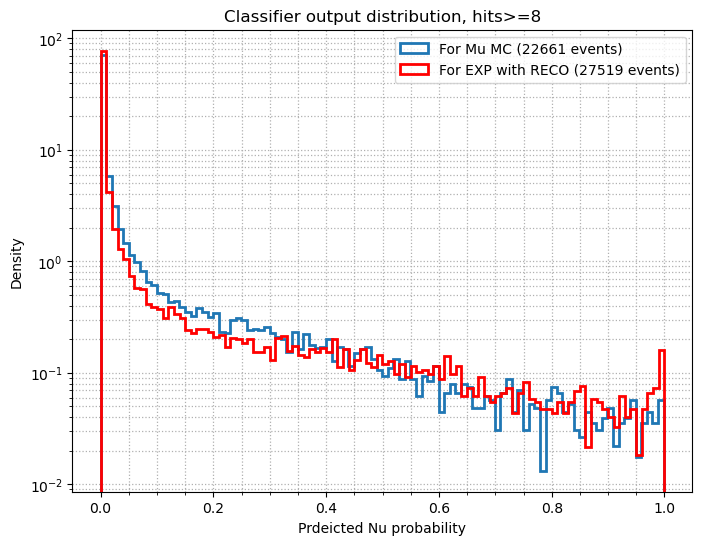

In [114]:
mc_probabilities = source_muons_all['class_prob']
mc_signal_hit_nums = source_muons_all['signal_hits']
mc_signal_strings_nums = source_muons_all['signal_strings']
mc_labels = source_muons_all['is_signal']

exp_probabilities = target_all['class_prob']

# Pmunu EXP VS MC
mc_mask = np.ones(len(mc_probabilities), dtype=bool) & (mc_signal_hit_nums>=8) & (mc_signal_strings_nums>=2) #& (mc_qgt20_num>=1)
labels_masked, mc_probabilities_masked = mc_labels[mc_mask], mc_probabilities[mc_mask]

exp_mask = np.ones(len(exp_probabilities), dtype=bool) #& (exp_qgt10_num>=2) & (exp_qgt20_num>=1)
exp_probas_masked = exp_probabilities[exp_mask]

reco_mask = np.ones(len(reco_probabilities), dtype=bool) & (reco_sig_hits_num>=8) #& (reco_qgt20_num>=1)
reco_probas_masked = reco_probabilities[reco_mask]

plt.figure(figsize=(8,6))
plt.hist(mc_probabilities_masked[~labels_masked], bins=100, density=True, log=True, histtype='step', lw=2., label=f'For Mu MC ({sum(mc_mask)} events)')
#plt.hist(exp_probas_masked, color='coral', bins=100, density=True, log=True, histtype='step', lw=2., label=f'For EXP ({sum(exp_mask)} events)')
plt.hist(reco_probas_masked, color='red', bins=100, density=True, log=True, histtype='step', lw=2., label=f'For EXP with RECO ({sum(reco_mask)} events)')
plt.title("Classifier output distribution, hits>=8")
plt.legend()
plt.grid(which='both', ls=':', lw=0.9)
plt.xlabel("Prdeicted Nu probability")
plt.ylabel("Density")
plt.minorticks_on()
plt.savefig(f"{fig_dir}/mc_muons_vs_reco_distributions.png", dpi=150, bbox_inches='tight')
plt.show()
plt.close()